In [5]:
from astropy.table import Table

In [7]:
data = Table.read('data/nihao_uhd_simulation_g8.26e11_xyz_positions_and_oxygen_ao.fits')
data

#readout the table columns so that we know what titles to use

x,y,z,A_O
float32,float32,float32,float64
10.020546,-15.421509,-3.241711,8.428943189382553
-13.487837,5.6635065,-0.8023056,8.671106847524642
6.642289,-0.13894245,-0.5859607,8.891595783233642
0.20393881,4.1123734,-0.14762174,8.977195146083831
-20.824045,6.971037,-1.7580608,8.326950194835662
5.3447924,18.439764,1.9853237,8.536727162599563
22.162682,5.025803,2.6751451,8.323067548274993
1.6786892,24.85231,0.67804474,8.362448933124542
19.999903,3.7504601,1.1096945,8.336060168743133


In [8]:
import numpy as np

In [9]:
#making the Rgal values

R_gal = np.sqrt(data['x']**2 + data['y']**2)

In [11]:
print(R_gal.min(), R_gal.max()) #just confimring we have no values above 25kpc

0.03219933 24.997658


Making the linear fit first so that we can plot the linear fit and legend as well as the residuals.

In [21]:
from scipy.stats import linregress
import matplotlib.pyplot as plt
import matplotlib

In [22]:
fit = linregress(R_gal, data['A_O'])

slope = fit.slope
intercept = fit.intercept
slope_std = fit.stderr
intercept_std = fit.intercept_stderr

print(f"Slope: {slope} ± {slope_std}")
print(f"Intercept: {intercept} ± {intercept_std}")

Slope: -0.034196472443601494 ± 1.480236380149793e-05
Intercept: 9.127839305492154 ± 0.00023227641726529497


In [23]:
#computing residuals for panel b
predicted_AO = slope * R_gal + intercept
residuals = data['A_O'] - predicted_AO

In [25]:
import os
os.makedirs('figures', exist_ok=True)

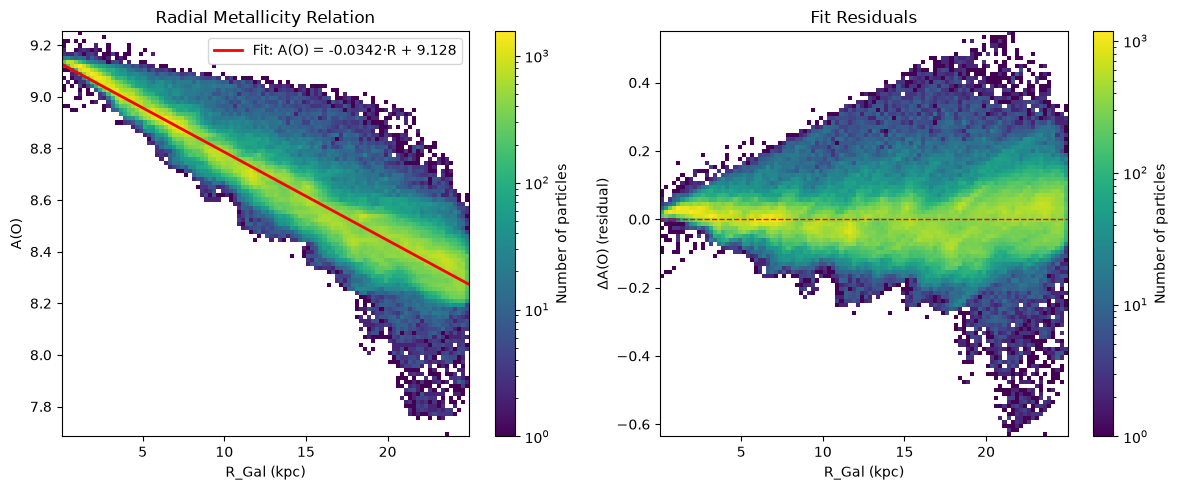

In [27]:
fig,axes = plt.subplots(1,2, figsize = (12, 5))

#panel a - Rgal vs AO
h = axes[0].hist2d(R_gal, data['A_O'], bins=100, norm=matplotlib.colors.LogNorm(), cmap='viridis')
fig.colorbar(h[3], ax=axes[0], label='Number of particles')

# overlay the fit line
r_line = np.linspace(R_gal.min(), R_gal.max(), 100)
fit_line = slope * r_line + intercept
axes[0].plot(r_line, fit_line, color='red', linewidth=2,
             label=f'Fit: A(O) = {slope:.4f}·R + {intercept:.3f}')

axes[0].set_xlabel('R_Gal (kpc)')
axes[0].set_ylabel('A(O)')
axes[0].set_title('Radial Metallicity Relation')
axes[0].legend()

# Panel (b)- Residuals
h2 = axes[1].hist2d(R_gal, residuals, bins=100, norm=matplotlib.colors.LogNorm(), cmap='viridis')
fig.colorbar(h2[3], ax=axes[1], label='Number of particles')
axes[1].axhline(0, color='red', linestyle='--', linewidth=1)
axes[1].set_xlabel('R_Gal (kpc)')
axes[1].set_ylabel('ΔA(O) (residual)')
axes[1].set_title('Fit Residuals')

plt.tight_layout()
plt.savefig('figures/task3_metallicity_gradient.png', dpi=150)
plt.show()


The plots above show the densit metallicity relation and the fit reisiduals. The Linear fit is overlaid with the red line. The residuals of the fit is calculated by the predicted - observed values. 

The linear fit gives us values - 
  Slope: −0.0342 ± 0.0000148 dex/kpc
  Intercept: 9.128 ± 0.00023 dex

This shows a clear negative radial metallicity graident where the gas becomes more metal poor at larger galactrocentric radii, this is consistent with inside out disk formation. However there is a lot of scatter in the residuals panel suggesting the true relation may not be perfectly linear.

In [30]:
#determing the quality of the fit

rms = np.sqrt(np.mean(residuals**2))
print("overall root mean square of the data", rms)

overall root mean square of the data 0.07264613635487784


In [37]:
#splitting the galaxy into bins around different radii and computing the RMS for each slice

bins = [0,5,10,15,20,25]
for i in range(len(bins)-1):
    mask = (R_gal >= bins[i] & (R_gal < bins[i+1]))
    bin_rms = np.sqrt(np.mean(residuals[mask]**2))
    print(f"R_Gal {bins[i]}-{bins[i+1]} kpc: RMS = {bin_rms:.4f}")

R_Gal 0-5 kpc: RMS = 0.0726
R_Gal 5-10 kpc: RMS = 0.0729
R_Gal 10-15 kpc: RMS = 0.0726
R_Gal 15-20 kpc: RMS = 0.0729
R_Gal 20-25 kpc: RMS = 0.0726


In [38]:
for i in range(len(bins)-1):
    mask = (R_gal >= bins[i]) & (R_gal < bins[i+1])
    median_resid = np.median(residuals[mask])
    print(f"R_Gal {bins[i]}-{bins[i+1]} kpc: median residual = {median_resid:.4f}")

R_Gal 0-5 kpc: median residual = 0.0196
R_Gal 5-10 kpc: median residual = -0.0030
R_Gal 10-15 kpc: median residual = -0.0181
R_Gal 15-20 kpc: median residual = -0.0247
R_Gal 20-25 kpc: median residual = 0.0206


Goodness of fit discussion:

The overall RMS of the residuals is 0.0726dex, which the value is consistent across all radial bins, indicating the scatter around the fit does not change with galactocentric radius.
However the meadian residuals show a clear systematic pattern that the RMS misses, it is slightly positive at the small radii (+0.0196 at 0-5kps), near zero at 5-10 kpc (-0.003), becomes increasingly negative thorugh the middle radii (-0.018 at 10-15kpc, -0.025 at 20-25kpc), then goes positive again at the largest radii (+0.021 at 20-25kpc). This pattern suggests the relation is not perfectly linear, where the fit systematically overpredicts the metallicity in the mid radius range and underpredicts at the innermost and outermost radii.
